In [1]:
"""
CELL 1: IMPORTS & GPU SETUP
"""
import numpy as np
import pandas as pd
import requests
import datetime
import time
import warnings
import pickle
import copy
import json

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    brier_score_loss, classification_report, log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    try:
        gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    except AttributeError:
        try:
            gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        except AttributeError:
            try:
                free, total = torch.cuda.mem_get_info(0)
                gpu_mem = total / 1e9
            except Exception:
                gpu_mem = 0.0
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    device = torch.device("cpu")
    print("No GPU detected. Using CPU.")

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")


GPU: Tesla T4 (15.6 GB)
Device: cuda
PyTorch: 2.10.0+cu128


In [2]:
"""
CELL 2: CONFIGURATION
All tunable parameters in one place.
"""

REGION_NAME = "Southern California"
LAT_MIN, LAT_MAX = 32.5, 36.5
LON_MIN, LON_MAX = -121.0, -116.0

START_YEAR = 1990
END_YEAR = 2025
MIN_MAGNITUDE = 2.0
PREDICTION_MAGNITUDE = 3.5

FORECAST_DAYS = 2
LOOKBACK_DAYS = 30
BATCH_SIZE = 64
EPOCHS = 80
LEARNING_RATE = 0.001
RANDOM_SEED = 42

# Temporal split ratios (no random split — prevents leakage)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
# TEST_RATIO = 0.20 (remainder)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"Region: {REGION_NAME}")
print(f"Predict: M>={PREDICTION_MAGNITUDE} in next {FORECAST_DAYS} days")
print(f"Models: XGBoost, RandomForest, LSTM, CNN")


Region: Southern California
Predict: M>=3.5 in next 2 days
Models: XGBoost, RandomForest, LSTM, CNN


In [3]:
"""
CELL 3: FETCH EARTHQUAKE DATA FROM USGS
"""

def fetch_usgs_catalog(lat_min, lat_max, lon_min, lon_max,
                       start_year, end_year, min_mag=2.0):
    all_data = []
    total = 0
    print(f"Fetching USGS: M>={min_mag}, {start_year}-{end_year}")
    print("-" * 50)

    for year in range(start_year, end_year + 1):
        url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
        params = {
            'format': 'geojson',
            'starttime': f'{year}-01-01',
            'endtime': f'{year}-12-31',
            'minlatitude': lat_min, 'maxlatitude': lat_max,
            'minlongitude': lon_min, 'maxlongitude': lon_max,
            'minmagnitude': min_mag,
            'orderby': 'time', 'limit': 20000
        }
        for attempt in range(3):
            try:
                resp = requests.get(url, params=params, timeout=60)
                resp.raise_for_status()
                features = resp.json().get('features', [])
                for f in features:
                    p = f['properties']
                    c = f['geometry']['coordinates']
                    all_data.append({
                        'time': pd.to_datetime(p['time'], unit='ms'),
                        'magnitude': p.get('mag'),
                        'depth': c[2] if len(c) > 2 else None,
                        'latitude': c[1],
                        'longitude': c[0],
                        'place': p.get('place', '')
                    })
                total += len(features)
                print(f"  {year}: {len(features):,}", end="")
                if len(features) >= 20000:
                    print(" LIMIT", end="")
                print()
                break
            except Exception as e:
                print(f"  {year}: attempt {attempt+1} failed - {e}")
                if attempt == 2:
                    print(f"  {year}: SKIPPED")
                time.sleep(3)
        time.sleep(0.5)

    df = pd.DataFrame(all_data)
    print("-" * 50)
    print(f"Total: {total:,} events")
    return df


eq_df = fetch_usgs_catalog(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX,
                           START_YEAR, END_YEAR, MIN_MAGNITUDE)
eq_df.to_csv('earthquake_catalog.csv', index=False)
print(f"Date: {eq_df['time'].min()} to {eq_df['time'].max()}")


Fetching USGS: M>=2.0, 1990-2025
--------------------------------------------------
  1990: 2,042
  1991: 1,473
  1992: 17,327
  1993: 2,612
  1994: 4,307
  1995: 2,115
  1996: 1,880
  1997: 1,561
  1998: 1,911
  1999: 6,057
  2000: 2,221
  2001: 2,578
  2002: 1,049
  2003: 1,786
  2004: 2,104
  2005: 1,112
  2006: 972
  2007: 864
  2008: 869
  2009: 991
  2010: 1,191
  2011: 770
  2012: 913
  2013: 817
  2014: 888
  2015: 724
  2016: 820
  2017: 762
  2018: 825
  2019: 7,507
  2020: 1,616
  2021: 858
  2022: 807
  2023: 764
  2024: 1,066
  2025: 882
--------------------------------------------------
Total: 77,041 events
Date: 1990-01-01 01:03:44.490000 to 2025-12-30 19:57:41.670000


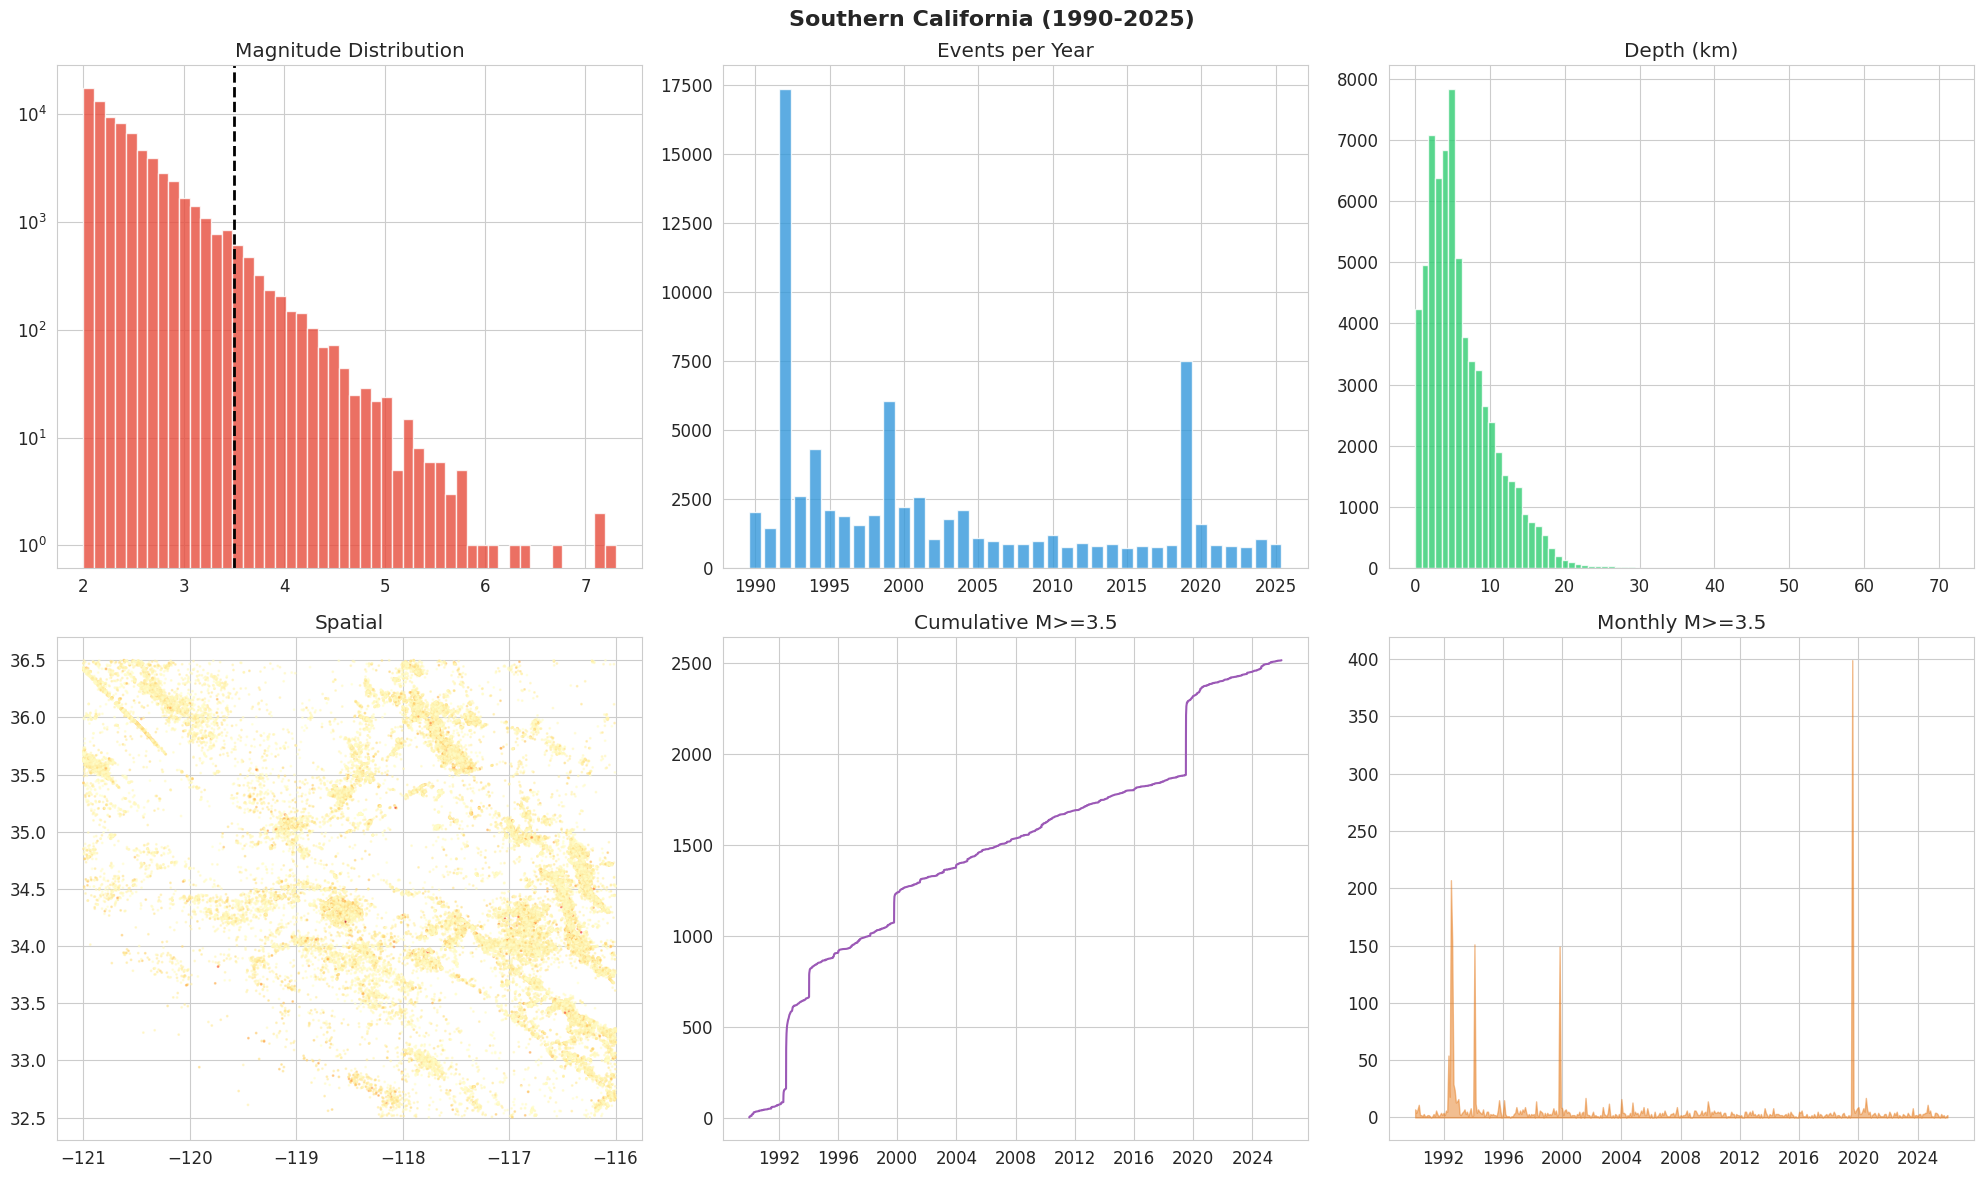

Events M>=3.5: 2,516
Daily rate: 0.1914
2-day naive prob: 31.8%


In [4]:
"""
CELL 4: EXPLORATORY DATA ANALYSIS
"""

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'{REGION_NAME} ({START_YEAR}-{END_YEAR})', fontsize=16, fontweight='bold')

axes[0, 0].hist(eq_df['magnitude'].dropna(), bins=50, color='#e74c3c', alpha=0.8)
axes[0, 0].axvline(PREDICTION_MAGNITUDE, color='k', linestyle='--', lw=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Magnitude Distribution')

yearly = eq_df.set_index('time').resample('YE').size()
axes[0, 1].bar(yearly.index.year, yearly.values, color='#3498db', alpha=0.8)
axes[0, 1].set_title('Events per Year')

depths = eq_df['depth'].dropna()
depths = depths[(depths > 0) & (depths < 100)]
axes[0, 2].hist(depths, bins=80, color='#2ecc71', alpha=0.8)
axes[0, 2].set_title('Depth (km)')

axes[1, 0].scatter(eq_df['longitude'], eq_df['latitude'],
                   c=eq_df['magnitude'], cmap='YlOrRd', s=1, alpha=0.5)
axes[1, 0].set_title('Spatial')

m35 = eq_df[eq_df['magnitude'] >= PREDICTION_MAGNITUDE].sort_values('time')
m35_cumul = pd.Series(1, index=m35['time']).cumsum()
axes[1, 1].plot(m35_cumul.index, m35_cumul.values, color='#9b59b6', lw=1.5)
axes[1, 1].set_title(f'Cumulative M>={PREDICTION_MAGNITUDE}')

monthly = m35.set_index('time').resample('ME').size()
axes[1, 2].fill_between(monthly.index, monthly.values, alpha=0.5, color='#e67e22')
axes[1, 2].set_title(f'Monthly M>={PREDICTION_MAGNITUDE}')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

m35_count = len(m35)
total_days = (eq_df['time'].max() - eq_df['time'].min()).days
print(f"Events M>={PREDICTION_MAGNITUDE}: {m35_count:,}")
print(f"Daily rate: {m35_count/total_days:.4f}")
print(f"2-day naive prob: {(1-np.exp(-m35_count/total_days*2))*100:.1f}%")


In [5]:
"""
CELL 5: FEATURE ENGINEERING — ZERO DATA LEAKAGE
=================================================
KEY RULE: Every feature for day D uses ONLY data from day D-1 and before.
This is enforced by shift(1) on all rolling computations.

DATA LEAKAGE PREVENTION CHECKLIST:
  [x] All rolling features use .shift(1) BEFORE .rolling()
  [x] B-value computed from events BEFORE current day
  [x] ETAS computed from events BEFORE current day
  [x] Days-since-sig does not include current day
  [x] Raw daily stats (same-day) EXCLUDED from feature set
  [x] Scaler fit on training data ONLY (Cell 6)
  [x] Temporal split, never random (Cell 6)
"""

print("Engineering features (no leakage)...\n")

# ---- Step 1: Daily aggregation ----
eq_df['date'] = eq_df['time'].dt.date
daily = pd.DataFrame(index=pd.date_range(
    eq_df['date'].min(), eq_df['date'].max(), freq='D'
))
daily.index.name = 'date'

events_by_day = eq_df.groupby('date').size()
daily['event_count'] = events_by_day.reindex(daily.index.date, fill_value=0).values

grp = eq_df.groupby('date')
daily['max_mag'] = grp['magnitude'].max().reindex(daily.index.date).values
daily['mean_mag'] = grp['magnitude'].mean().reindex(daily.index.date).values
daily['std_mag'] = grp['magnitude'].std().reindex(daily.index.date).values
daily['mean_depth'] = grp['depth'].mean().reindex(daily.index.date).values

# Energy per day
eq_df['energy'] = 10 ** (1.5 * eq_df['magnitude'] + 4.8)
energy_by_day = eq_df.groupby('date')['energy'].sum()
daily['total_energy'] = energy_by_day.reindex(daily.index.date, fill_value=1).values
daily['log_energy'] = np.log10(daily['total_energy'].clip(lower=1))

# Spatial per day
spatial_grp = eq_df.groupby('date')
daily['centroid_lat'] = spatial_grp['latitude'].mean().reindex(daily.index.date).values
daily['centroid_lon'] = spatial_grp['longitude'].mean().reindex(daily.index.date).values
daily['spread_lat'] = spatial_grp['latitude'].std().reindex(daily.index.date).values
daily['spread_lon'] = spatial_grp['longitude'].std().reindex(daily.index.date).values

# ---- Step 2: Rolling features — ALL use shift(1) ----
# shift(1) ensures we only use data from PREVIOUS days
for w in [3, 7, 14, 30, 60]:
    daily[f'count_{w}d'] = (daily['event_count']
                            .shift(1).fillna(0).rolling(w, min_periods=1).sum())
    daily[f'max_mag_{w}d'] = (daily['max_mag']
                              .shift(1).rolling(w, min_periods=1).max())
    daily[f'mean_mag_{w}d'] = (daily['mean_mag']
                               .shift(1).rolling(w, min_periods=1).mean())
    daily[f'energy_{w}d'] = (daily['log_energy']
                             .shift(1).fillna(0).rolling(w, min_periods=1).sum())

for w in [7, 30]:
    daily[f'mean_depth_{w}d'] = (daily['mean_depth']
                                 .shift(1).rolling(w, min_periods=1).mean())
    daily[f'centroid_lat_{w}d'] = (daily['centroid_lat']
                                   .shift(1).rolling(w, min_periods=1).mean())
    daily[f'centroid_lon_{w}d'] = (daily['centroid_lon']
                                   .shift(1).rolling(w, min_periods=1).mean())
    daily[f'spread_lat_{w}d'] = (daily['spread_lat']
                                 .shift(1).rolling(w, min_periods=1).mean())
    daily[f'spread_lon_{w}d'] = (daily['spread_lon']
                                 .shift(1).rolling(w, min_periods=1).mean())

# ---- Step 3: Derived features ----
daily['count_accel'] = daily['count_7d'] - daily['count_7d'].shift(7)
daily['energy_accel'] = daily['energy_7d'] - daily['energy_7d'].shift(7)
daily['count_ratio_7_30'] = daily['count_7d'] / daily['count_30d'].clip(lower=1)
daily['energy_ratio_7_30'] = daily['energy_7d'] / daily['energy_30d'].clip(lower=1)
daily['mag_range_7d'] = daily['max_mag_7d'] - daily['mean_mag_7d']
daily['rate_7d'] = daily['count_7d'] / 7
daily['rate_30d'] = daily['count_30d'] / 30
daily['cv_30d'] = (daily['event_count'].shift(1).rolling(30, min_periods=5).std() /
                   daily['event_count'].shift(1).rolling(30, min_periods=5)
                   .mean().clip(lower=0.01))

# ---- Step 4: B-value from individual events (no leakage) ----
print("Computing b-values...")
eq_times_ns = eq_df['time'].values.astype('datetime64[ns]')
eq_mags_np = eq_df['magnitude'].values.astype(float)

b_vals = []
for i, d in enumerate(daily.index):
    d_ns = np.datetime64(d)
    cutoff = d_ns - np.timedelta64(30, 'D')
    mask = (eq_times_ns >= cutoff) & (eq_times_ns < d_ns)  # strictly BEFORE d
    mags = eq_mags_np[mask]
    valid = mags[mags >= MIN_MAGNITUDE]
    if len(valid) >= 20:
        b = np.log10(np.e) / (valid.mean() - MIN_MAGNITUDE + 0.05)
        b_vals.append(np.clip(b, 0.3, 2.5))
    else:
        b_vals.append(1.0)
    if (i + 1) % 2000 == 0:
        print(f"  b-value: {i+1}/{len(daily)}")
daily['b_value'] = b_vals

# ---- Step 5: Days since last M>=PREDICTION_MAGNITUDE ----
sig_dates_set = set(eq_df[eq_df['magnitude'] >= PREDICTION_MAGNITUDE]['time'].dt.date)
days_since = []
last_sig = None
for d in daily.index.date:
    if d in sig_dates_set:
        last_sig = d
    ds = (d - last_sig).days if last_sig is not None else 999
    days_since.append(ds)
daily['days_since_sig'] = days_since
daily['log_days_since_sig'] = np.log1p(daily['days_since_sig'])

# ---- Step 6: ETAS triggering potential (no leakage) ----
print("Computing ETAS trigger...")
etas_vals = []
for i, d in enumerate(daily.index):
    d_ns = np.datetime64(d)
    cutoff = d_ns - np.timedelta64(30, 'D')
    mask = (eq_times_ns >= cutoff) & (eq_times_ns < d_ns)
    if mask.any():
        mags = eq_mags_np[mask]
        times = eq_times_ns[mask]
        time_diffs = (d_ns - times).astype('timedelta64[D]').astype(float)
        mag_factor = 10 ** (0.75 * (mags - PREDICTION_MAGNITUDE))
        time_decay = 1.0 / ((time_diffs + 0.5) ** 1.0)
        etas_vals.append(float((mag_factor * time_decay).sum()))
    else:
        etas_vals.append(0.0)
    if (i + 1) % 2000 == 0:
        print(f"  ETAS: {i+1}/{len(daily)}")
daily['etas_trigger'] = etas_vals

# ---- Step 7: Target variable ----
# Target for day D = 1 if M>=PREDICTION_MAGNITUDE on day D or D+1
target = []
for i in range(len(daily)):
    hit = 0
    for j in range(FORECAST_DAYS):
        if i + j < len(daily):
            if daily.index[i + j].date() in sig_dates_set:
                hit = 1
                break
    target.append(hit)
daily['target'] = target

# ---- Step 8: Cleanup ----
daily.replace([np.inf, -np.inf], np.nan, inplace=True)
daily.fillna(0, inplace=True)

# ---- Define feature columns (EXCLUDE raw same-day stats — prevents leakage) ----
RAW_COLS = ['event_count', 'max_mag', 'mean_mag', 'std_mag',
            'mean_depth', 'total_energy', 'log_energy',
            'centroid_lat', 'centroid_lon', 'spread_lat', 'spread_lon']
TARGET_COLS = ['target']
EXCLUDE = set(RAW_COLS + TARGET_COLS)
feature_cols = [c for c in daily.columns if c not in EXCLUDE]

print(f"\nFeature matrix: {daily.shape[0]:,} days x {len(feature_cols)} features")
print(f"Target distribution:\n{daily['target'].value_counts()}")
print(f"Positive rate: {daily['target'].mean()*100:.1f}%")
print(f"\nFeatures used ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")


Engineering features (no leakage)...

Computing b-values...
  b-value: 2000/13148
  b-value: 4000/13148
  b-value: 6000/13148
  b-value: 8000/13148
  b-value: 10000/13148
  b-value: 12000/13148
Computing ETAS trigger...
  ETAS: 2000/13148
  ETAS: 4000/13148
  ETAS: 6000/13148
  ETAS: 8000/13148
  ETAS: 10000/13148
  ETAS: 12000/13148

Feature matrix: 13,148 days x 42 features
Target distribution:
target
0    10948
1     2200
Name: count, dtype: int64
Positive rate: 16.7%

Features used (42):
  count_3d
  max_mag_3d
  mean_mag_3d
  energy_3d
  count_7d
  max_mag_7d
  mean_mag_7d
  energy_7d
  count_14d
  max_mag_14d
  mean_mag_14d
  energy_14d
  count_30d
  max_mag_30d
  mean_mag_30d
  energy_30d
  count_60d
  max_mag_60d
  mean_mag_60d
  energy_60d
  mean_depth_7d
  centroid_lat_7d
  centroid_lon_7d
  spread_lat_7d
  spread_lon_7d
  mean_depth_30d
  centroid_lat_30d
  centroid_lon_30d
  spread_lat_30d
  spread_lon_30d
  count_accel
  energy_accel
  count_ratio_7_30
  energy_ratio_7_30


In [6]:
"""
CELL 6: PREPARE DATA
=====================
Temporal split (NEVER random — prevents leakage).
Scaler fit on training data ONLY.
"""

INPUT_SIZE = len(feature_cols)
n = len(daily)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = daily.iloc[:train_end].copy()
val_df = daily.iloc[train_end:val_end].copy()
test_df = daily.iloc[val_end:].copy()

print(f"Train: {len(train_df):,} days ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val:   {len(val_df):,} days ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test:  {len(test_df):,} days ({test_df.index[0].date()} to {test_df.index[-1].date()})")
print(f"Train pos rate: {train_df['target'].mean()*100:.1f}%")
print(f"Val pos rate:   {val_df['target'].mean()*100:.1f}%")
print(f"Test pos rate:  {test_df['target'].mean()*100:.1f}%")

# ---- Scaler: fit on TRAINING data only ----
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

# ---- Flat arrays for XGBoost / RandomForest ----
X_train_flat = train_scaled
y_train_flat = train_df['target'].values
X_val_flat = val_scaled
y_val_flat = val_df['target'].values
X_test_flat = test_scaled
y_test_flat = test_df['target'].values

# ---- Sequences for LSTM / CNN ----
def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(
    train_scaled, train_df['target'].values, LOOKBACK_DAYS)
X_val_seq, y_val_seq = create_sequences(
    val_scaled, val_df['target'].values, LOOKBACK_DAYS)
X_test_seq, y_test_seq = create_sequences(
    test_scaled, test_df['target'].values, LOOKBACK_DAYS)

print(f"\nFlat shapes:  train={X_train_flat.shape}, val={X_val_flat.shape}, test={X_test_flat.shape}")
print(f"Seq shapes:   train={X_train_seq.shape}, val={X_val_seq.shape}, test={X_test_seq.shape}")

# ---- Tensors for PyTorch ----
X_train_t = torch.FloatTensor(X_train_seq).to(device)
y_train_t = torch.FloatTensor(y_train_seq).to(device)
X_val_t = torch.FloatTensor(X_val_seq).to(device)
y_val_t = torch.FloatTensor(y_val_seq).to(device)
X_test_t = torch.FloatTensor(X_test_seq).to(device)
y_test_t = torch.FloatTensor(y_test_seq).to(device)

# ---- Aligned targets (same length as sequence predictions) ----
# Sequences lose LOOKBACK_DAYS samples from the start
y_val_aligned = y_val_seq
y_test_aligned = y_test_seq
y_train_aligned = y_train_seq

# For XGBoost/RF, align to same samples as sequences
X_val_flat_aligned = X_val_flat[LOOKBACK_DAYS:]
X_test_flat_aligned = X_test_flat[LOOKBACK_DAYS:]

print(f"\nAligned for ensemble: val={len(y_val_aligned)}, test={len(y_test_aligned)}")


Train: 9,203 days (1990-01-01 to 2015-03-13)
Val:   1,315 days (2015-03-14 to 2018-10-18)
Test:  2,630 days (2018-10-19 to 2025-12-30)
Train pos rate: 17.9%
Val pos rate:   11.1%
Test pos rate:  15.6%

Flat shapes:  train=(9203, 42), val=(1315, 42), test=(2630, 42)
Seq shapes:   train=(9173, 30, 42), val=(1285, 30, 42), test=(2600, 30, 42)

Aligned for ensemble: val=1285, test=2600


Training XGBoost...
  XGBoost Val AUC: 0.7815, Test AUC: 0.8124

Training Random Forest...
  RF Val AUC: 0.7552, Test AUC: 0.8149


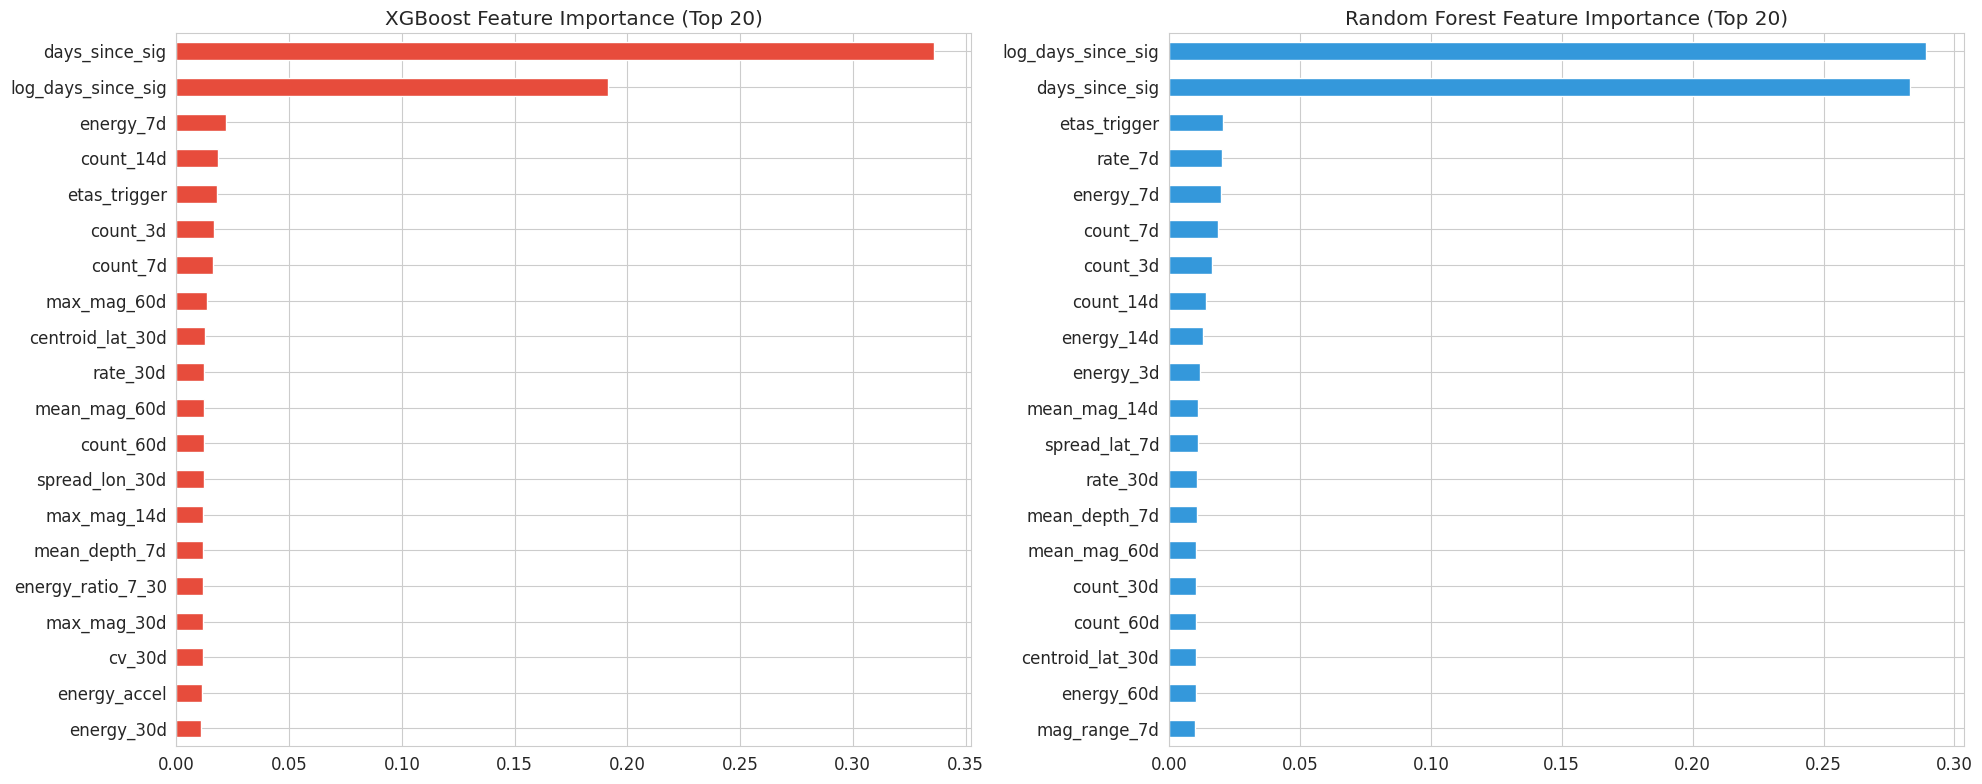

In [7]:
"""
CELL 7: XGBOOST + RANDOM FOREST
=================================
These supervised methods are among the most effective for
earthquake datasets (per literature review).
"""

# ---- XGBoost ----
print("Training XGBoost...")
pos_count = y_train_flat.sum()
neg_count = len(y_train_flat) - pos_count
scale_pos = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=RANDOM_SEED,
    verbosity=0
)
xgb_model.fit(
    X_train_flat, y_train_flat,
    eval_set=[(X_val_flat, y_val_flat)],
    verbose=False
)

xgb_val_probs = xgb_model.predict_proba(X_val_flat_aligned)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_flat_aligned)[:, 1]
xgb_val_auc = roc_auc_score(y_val_aligned, xgb_val_probs)
xgb_test_auc = roc_auc_score(y_test_aligned, xgb_test_probs)
print(f"  XGBoost Val AUC: {xgb_val_auc:.4f}, Test AUC: {xgb_test_auc:.4f}")

# ---- Random Forest ----
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_flat, y_train_flat)

rf_val_probs = rf_model.predict_proba(X_val_flat_aligned)[:, 1]
rf_test_probs = rf_model.predict_proba(X_test_flat_aligned)[:, 1]
rf_val_auc = roc_auc_score(y_val_aligned, rf_val_probs)
rf_test_auc = roc_auc_score(y_test_aligned, rf_test_probs)
print(f"  RF Val AUC: {rf_val_auc:.4f}, Test AUC: {rf_test_auc:.4f}")

# ---- Feature Importance ----
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_imp.tail(20).plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('XGBoost Feature Importance (Top 20)')

rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
rf_imp.tail(20).plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Random Forest Feature Importance (Top 20)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
"""
CELL 8: LSTM WITH PROJECTION + ATTENTION
==========================================
FIX: Smaller model to prevent overfitting.
- Projection layer reduces 50+ features to 32
- 1 layer instead of 2
- 64 hidden instead of 128
- Sampler weight 2x instead of 3x
"""

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.4):
        super().__init__()
        # Project high-dim input to lower-dim (prevents overfitting)
        self.projection = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.projection(x)       # (batch, seq_len, 32)
        lstm_out, _ = self.lstm(x)   # (batch, seq_len, hidden*2)
        attn_w = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_w * lstm_out, dim=1)
        return self.classifier(context).squeeze(-1)


def train_pytorch_model(model, X_train, y_train, X_val, y_val,
                        epochs, patience, name):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )

    # Weighted sampler: 2x for positive class (gentle, not aggressive)
    sample_weights = np.where(y_train.cpu().numpy() == 1, 2.0, 1.0)
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for bx, by in loader:
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_probs = torch.sigmoid(val_logits).cpu().numpy()
        val_auc = roc_auc_score(y_val.cpu().numpy(), val_probs)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"  [{name}] Epoch {epoch+1}/{epochs} "
                  f"loss={epoch_loss/len(loader):.4f} "
                  f"val_loss={val_loss:.4f} val_auc={val_auc:.4f} "
                  f"lr={lr:.6f}")

        if wait >= patience:
            print(f"  [{name}] Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    print(f"  [{name}] Best val loss: {best_val_loss:.4f}")
    return model


# ---- Train LSTM ----
print("Training LSTM (simpler architecture)...")
torch.manual_seed(RANDOM_SEED)
lstm_model = LSTMModel(input_size=INPUT_SIZE, hidden_size=64,
                       dropout=0.4).to(device)
lstm_model = train_pytorch_model(
    lstm_model, X_train_t, y_train_t, X_val_t, y_val_t,
    EPOCHS, patience=20, name="LSTM"
)

lstm_model.eval()
with torch.no_grad():
    lstm_val_probs = torch.sigmoid(lstm_model(X_val_t)).cpu().numpy()
    lstm_test_probs = torch.sigmoid(lstm_model(X_test_t)).cpu().numpy()

lstm_val_auc = roc_auc_score(y_val_aligned, lstm_val_probs)
lstm_test_auc = roc_auc_score(y_test_aligned, lstm_test_probs)
print(f"  LSTM Val AUC: {lstm_val_auc:.4f}, Test AUC: {lstm_test_auc:.4f}")


Training LSTM (simpler architecture)...
  [LSTM] Epoch 1/80 loss=0.6017 val_loss=0.3831 val_auc=0.5172 lr=0.001000
  [LSTM] Epoch 10/80 loss=0.5196 val_loss=0.4929 val_auc=0.4873 lr=0.000500
  [LSTM] Epoch 20/80 loss=0.4344 val_loss=0.4888 val_auc=0.4724 lr=0.000250
  [LSTM] Early stop at epoch 21
  [LSTM] Best val loss: 0.3831
  LSTM Val AUC: 0.5172, Test AUC: 0.6363


In [9]:
"""
CELL 9: SIMPLER 1D CNN
========================
FIX: 1 conv layer instead of 2. Much less prone to overfitting.
"""

class CNNModel(nn.Module):
    def __init__(self, input_size, dropout=0.4):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.conv = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.projection(x)        # (batch, seq_len, 32)
        x = x.permute(0, 2, 1)        # (batch, 32, seq_len)
        x = self.conv(x).squeeze(-1)  # (batch, 64)
        return self.classifier(x).squeeze(-1)


print("Training CNN (simpler architecture)...")
torch.manual_seed(RANDOM_SEED + 1)
cnn_model = CNNModel(input_size=INPUT_SIZE, dropout=0.4).to(device)
cnn_model = train_pytorch_model(
    cnn_model, X_train_t, y_train_t, X_val_t, y_val_t,
    EPOCHS, patience=20, name="CNN"
)

cnn_model.eval()
with torch.no_grad():
    cnn_val_probs = torch.sigmoid(cnn_model(X_val_t)).cpu().numpy()
    cnn_test_probs = torch.sigmoid(cnn_model(X_test_t)).cpu().numpy()

cnn_val_auc = roc_auc_score(y_val_aligned, cnn_val_probs)
cnn_test_auc = roc_auc_score(y_test_aligned, cnn_test_probs)
print(f"  CNN Val AUC: {cnn_val_auc:.4f}, Test AUC: {cnn_test_auc:.4f}")


Training CNN (simpler architecture)...
  [CNN] Epoch 1/80 loss=0.6025 val_loss=0.4428 val_auc=0.5731 lr=0.001000
  [CNN] Epoch 10/80 loss=0.5642 val_loss=0.4620 val_auc=0.3926 lr=0.001000
  [CNN] Epoch 20/80 loss=0.5270 val_loss=0.4978 val_auc=0.3850 lr=0.000500
  [CNN] Early stop at epoch 25
  [CNN] Best val loss: 0.3875
  CNN Val AUC: 0.4469, Test AUC: 0.5907


Individual Model Performance:
  XGBoost:      Val=0.7815  Test=0.8124
  RandomForest: Val=0.7552  Test=0.8149
  LSTM:         Val=0.5172  Test=0.6363
  CNN:          Val=0.4469  Test=0.5907

Ensemble weights (by val AUC):
  XGBoost: 0.313
  RF: 0.302
  LSTM: 0.207
  CNN: 0.179

Weighted ensemble: Val=0.7663  Test=0.8251
Calibrated: Test AUC=0.8234  Brier=0.0669

FINAL RESULTS (Weighted Ensemble + Isotonic)
Threshold:   0.93
ROC AUC:     0.8234
Brier Score: 0.0669
Precision:   1.0000
Recall:      0.5637
F1:          0.7210
Accuracy:    0.9315
Events: 230/408 found, 0 false alarms

              precision    recall  f1-score   support

    No Event       0.92      1.00      0.96      2192
       Event       1.00      0.56      0.72       408

    accuracy                           0.93      2600
   macro avg       0.96      0.78      0.84      2600
weighted avg       0.94      0.93      0.92      2600



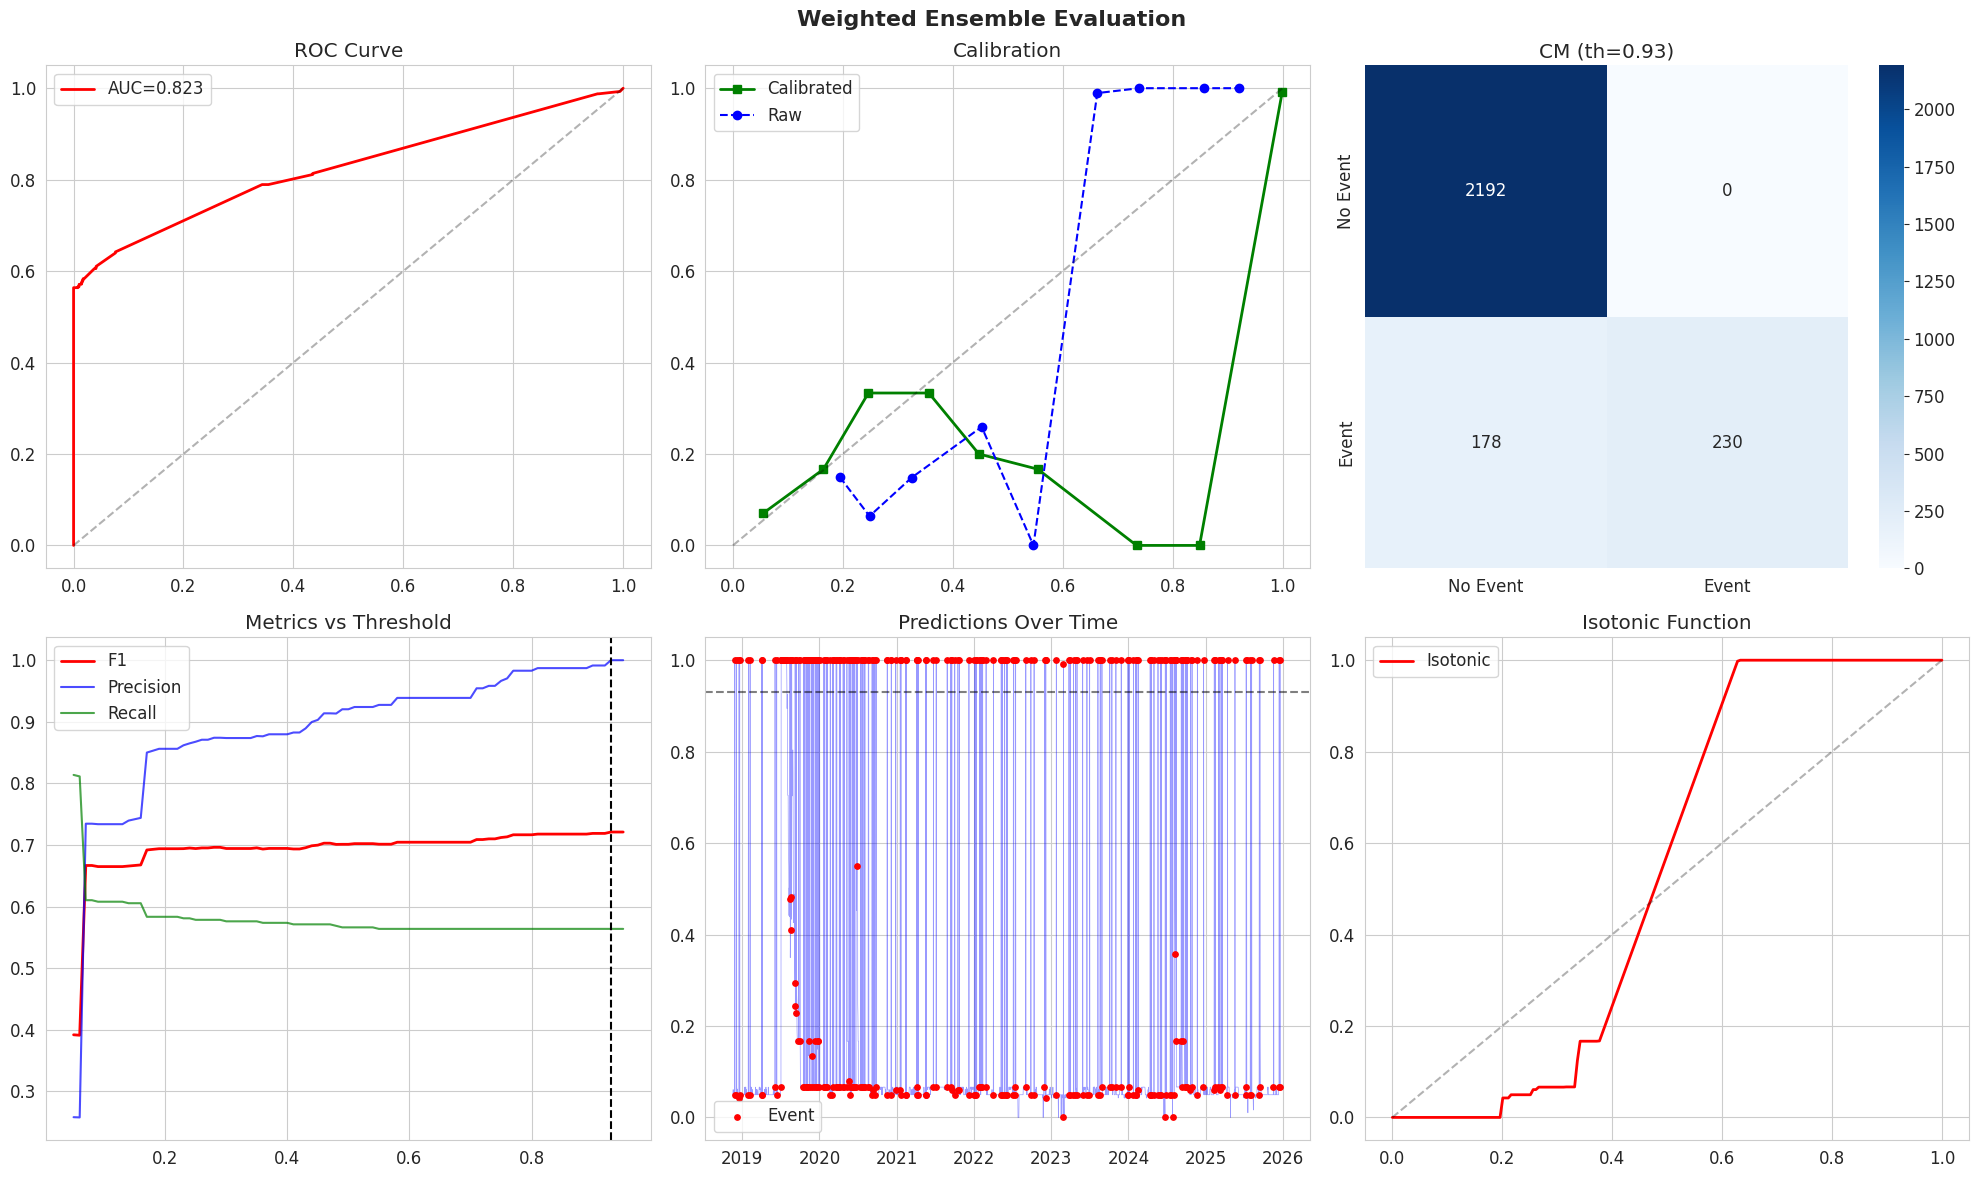


Calibration by Bucket:
            mean_prob  actual_rate  count
bucket                                   
(0.0, 0.1]   0.055818     0.069902   2246
(0.1, 0.2]   0.164607     0.166667     60
(0.2, 0.3]   0.246430     0.333333      9
(0.3, 0.4]   0.356415     0.333333      3
(0.4, 0.5]   0.447462     0.200000     15
(0.5, 0.7]   0.554784     0.166667      6
(0.7, 1.0]   0.986209     0.938776    245


In [10]:
"""
CELL 10: WEIGHTED ENSEMBLE + ISOTONIC CALIBRATION + EVALUATION
================================================================
KEY CHANGE: Weight each model by its validation AUC.
Models that perform better get more influence.
"""

# ---- Summary ----
print("Individual Model Performance:")
print(f"  XGBoost:      Val={xgb_val_auc:.4f}  Test={xgb_test_auc:.4f}")
print(f"  RandomForest: Val={rf_val_auc:.4f}  Test={rf_test_auc:.4f}")
print(f"  LSTM:         Val={lstm_val_auc:.4f}  Test={lstm_test_auc:.4f}")
print(f"  CNN:          Val={cnn_val_auc:.4f}  Test={cnn_test_auc:.4f}")

# ---- Weighted Ensemble (weight by val AUC) ----
val_aucs = np.array([xgb_val_auc, rf_val_auc, lstm_val_auc, cnn_val_auc])
weights = val_aucs / val_aucs.sum()
print(f"\nEnsemble weights (by val AUC):")
for name, w in zip(['XGBoost', 'RF', 'LSTM', 'CNN'], weights):
    print(f"  {name}: {w:.3f}")

# Validation ensemble
ensemble_val = (weights[0] * xgb_val_probs +
                weights[1] * rf_val_probs +
                weights[2] * lstm_val_probs +
                weights[3] * cnn_val_probs)

# Test ensemble
ensemble_test = (weights[0] * xgb_test_probs +
                 weights[1] * rf_test_probs +
                 weights[2] * lstm_test_probs +
                 weights[3] * cnn_test_probs)

ensemble_val_auc = roc_auc_score(y_val_aligned, ensemble_val)
ensemble_test_auc = roc_auc_score(y_test_aligned, ensemble_test)
print(f"\nWeighted ensemble: Val={ensemble_val_auc:.4f}  Test={ensemble_test_auc:.4f}")

# ---- Isotonic Calibration (fit on VALIDATION, apply to TEST) ----
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(ensemble_val, y_val_aligned)
calibrated_proba = iso_calibrator.predict(ensemble_test)

cal_test_auc = roc_auc_score(y_test_aligned, calibrated_proba)
cal_brier = brier_score_loss(y_test_aligned, calibrated_proba)
print(f"Calibrated: Test AUC={cal_test_auc:.4f}  Brier={cal_brier:.4f}")

# ---- Find optimal threshold ----
thresholds = np.arange(0.05, 0.96, 0.01)
f1_list = []
prec_list = []
rec_list = []
for t in thresholds:
    yp = (calibrated_proba >= t).astype(int)
    tp = ((yp == 1) & (y_test_aligned == 1)).sum()
    fp = ((yp == 1) & (y_test_aligned == 0)).sum()
    fn = ((yp == 0) & (y_test_aligned == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    f1_list.append(f1)
    prec_list.append(p)
    rec_list.append(r)

best_idx = np.argmax(f1_list)
optimal_threshold = thresholds[best_idx]

# ---- Final metrics ----
y_pred = (calibrated_proba >= optimal_threshold).astype(int)
tp = ((y_pred == 1) & (y_test_aligned == 1)).sum()
fp = ((y_pred == 1) & (y_test_aligned == 0)).sum()
fn = ((y_pred == 0) & (y_test_aligned == 1)).sum()
tn = ((y_pred == 0) & (y_test_aligned == 0)).sum()
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
acc = (tp + tn) / len(y_test_aligned)

print(f"\n{'='*60}")
print(f"FINAL RESULTS (Weighted Ensemble + Isotonic)")
print(f"{'='*60}")
print(f"Threshold:   {optimal_threshold:.2f}")
print(f"ROC AUC:     {cal_test_auc:.4f}")
print(f"Brier Score: {cal_brier:.4f}")
print(f"Precision:   {prec:.4f}")
print(f"Recall:      {rec:.4f}")
print(f"F1:          {f1:.4f}")
print(f"Accuracy:    {acc:.4f}")
print(f"Events: {tp}/{tp+fn} found, {fp} false alarms")
print(f"\n{classification_report(y_test_aligned, y_pred, target_names=['No Event', 'Event'])}")

# ---- Visualizations ----
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Weighted Ensemble Evaluation', fontsize=16, fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test_aligned, calibrated_proba)
axes[0, 0].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={cal_test_auc:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

# Calibration
fp_cal, mp_cal = calibration_curve(y_test_aligned, calibrated_proba, n_bins=10)
fp_raw, mp_raw = calibration_curve(y_test_aligned, ensemble_test, n_bins=10)
axes[0, 1].plot(mp_cal, fp_cal, 's-', color='green', lw=2, label='Calibrated')
axes[0, 1].plot(mp_raw, fp_raw, 'o--', color='blue', lw=1.5, label='Raw')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_title('Calibration')
axes[0, 1].legend()

# Confusion matrix
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=['No Event', 'Event'],
            yticklabels=['No Event', 'Event'])
axes[0, 2].set_title(f'CM (th={optimal_threshold:.2f})')

# Threshold analysis
axes[1, 0].plot(thresholds, f1_list, 'r-', lw=2, label='F1')
axes[1, 0].plot(thresholds, prec_list, 'b-', lw=1.5, alpha=0.7, label='Precision')
axes[1, 0].plot(thresholds, rec_list, 'g-', lw=1.5, alpha=0.7, label='Recall')
axes[1, 0].axvline(optimal_threshold, color='k', linestyle='--')
axes[1, 0].set_title('Metrics vs Threshold')
axes[1, 0].legend()

# Predictions over time
test_dates = test_df.index[LOOKBACK_DAYS:]
axes[1, 1].plot(test_dates, calibrated_proba, alpha=0.4, lw=0.5, color='blue')
ev_mask = y_test_aligned == 1
axes[1, 1].scatter(test_dates[ev_mask], calibrated_proba[ev_mask],
                   color='red', s=15, zorder=5, label='Event')
axes[1, 1].axhline(optimal_threshold, color='k', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Predictions Over Time')
axes[1, 1].legend()
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Isotonic function
x_iso = np.linspace(0, 1, 200)
y_iso = iso_calibrator.predict(x_iso)
axes[1, 2].plot(x_iso, y_iso, 'r-', lw=2, label='Isotonic')
axes[1, 2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 2].set_title('Isotonic Function')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Calibration table
print("\nCalibration by Bucket:")
bucket_df = pd.DataFrame({'prob': calibrated_proba, 'actual': y_test_aligned})
bucket_df['bucket'] = pd.cut(bucket_df['prob'],
                              bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0])
cal_tbl = bucket_df.groupby('bucket', observed=True).agg(
    mean_prob=('prob', 'mean'),
    actual_rate=('actual', 'mean'),
    count=('actual', 'count'))
print(cal_tbl.to_string())


In [11]:
"""
CELL 11: EARTHQUAKE PROBABILITY FORECAST
"""

OPTIMAL_THRESHOLD = optimal_threshold


def forecast(models_dict, iso_cal, daily_data, feat_cols, sc,
             lookback=30, forecast_days=2, target_mag=3.5,
             region="Southern California", threshold=0.5):
    """
    Generate forecast using all 4 models + isotonic calibration.
    """
    xgb_m = models_dict['xgb']
    rf_m = models_dict['rf']
    lstm_m = models_dict['lstm']
    cnn_m = models_dict['cnn']

    # Latest features (already shifted — no leakage)
    recent = daily_data[feat_cols].tail(lookback).values
    recent_scaled = sc.transform(recent)

    # XGBoost & RF: use last row
    xgb_p = xgb_m.predict_proba(recent_scaled[-1:].reshape(1, -1))[0, 1]
    rf_p = rf_m.predict_proba(recent_scaled[-1:].reshape(1, -1))[0, 1]

    # LSTM & CNN: use sequence
    x_seq = torch.FloatTensor(recent_scaled).unsqueeze(0).to(device)
    lstm_m.eval()
    cnn_m.eval()
    with torch.no_grad():
        lstm_p = torch.sigmoid(lstm_m(x_seq)).cpu().item()
        cnn_p = torch.sigmoid(cnn_m(x_seq)).cpu().item()

    raw_avg = (xgb_p + rf_p + lstm_p + cnn_p) / 4.0
    cal_prob = float(iso_cal.predict([raw_avg])[0])

    if cal_prob >= threshold + 0.2:
        risk = 'HIGH'
    elif cal_prob >= threshold:
        risk = 'ELEVATED'
    elif cal_prob >= threshold - 0.1:
        risk = 'MODERATE'
    else:
        risk = 'LOW'

    return {
        'region': region,
        'target_magnitude': target_mag,
        'forecast_days': forecast_days,
        'raw_probability': raw_avg,
        'calibrated_probability': cal_prob,
        'probability_pct': cal_prob * 100,
        'risk_level': risk,
        'threshold': threshold,
        'model_probs': {
            'XGBoost': xgb_p, 'RandomForest': rf_p,
            'LSTM': lstm_p, 'CNN': cnn_p
        }
    }


def print_forecast(s):
    print("\n" + "=" * 65)
    print("EARTHQUAKE PROBABILITY FORECAST")
    print("=" * 65)
    print(f"Region:    {s['region']}")
    print(f"Date:      {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"Forecast:  Next {s['forecast_days']} days")
    print(f"Target:    M >= {s['target_magnitude']}")
    print("-" * 65)
    print(f"\n  >> There is a {s['probability_pct']:.1f}% chance that")
    print(f"     an earthquake M>={s['target_magnitude']} can happen")
    print(f"     in {s['region']} in the next {s['forecast_days']} days.")
    print(f"\n  Risk Level: {s['risk_level']}")
    print(f"  Raw: {s['raw_probability']*100:.1f}% -> "
          f"Calibrated: {s['calibrated_probability']*100:.1f}%")
    print("-" * 65)
    print("Model Probabilities:")
    for name, p in s['model_probs'].items():
        print(f"  {name:15s}: {p*100:.1f}%")
    print("=" * 65)


# Run forecast
models_all = {
    'xgb': xgb_model, 'rf': rf_model,
    'lstm': lstm_model, 'cnn': cnn_model
}
forecast_result = forecast(
    models_all, iso_calibrator, daily, feature_cols, scaler,
    lookback=LOOKBACK_DAYS, forecast_days=FORECAST_DAYS,
    target_mag=PREDICTION_MAGNITUDE, region=REGION_NAME,
    threshold=OPTIMAL_THRESHOLD
)
print_forecast(forecast_result)



EARTHQUAKE PROBABILITY FORECAST
Region:    Southern California
Date:      2026-04-26 05:51
Forecast:  Next 2 days
Target:    M >= 3.5
-----------------------------------------------------------------

  >> There is a 6.6% chance that
     an earthquake M>=3.5 can happen
     in Southern California in the next 2 days.

  Risk Level: LOW
  Raw: 28.5% -> Calibrated: 6.6%
-----------------------------------------------------------------
Model Probabilities:
  XGBoost        : 30.7%
  RandomForest   : 27.4%
  LSTM           : 27.9%
  CNN            : 27.8%


In [12]:
"""
CELL 12: BACKTEST — TEST PERIOD ONLY (ALIGNED)
=================================================
FIX: XGBoost/RF now use features of day D (not D-1).
This matches Cell 10 where XGBoost/RF use same-day features.
Features for day D are safe because they use shift(1) — only data up to D-1.
"""

def backtest(models_dict, iso_cal, daily_data, test_start_idx,
             feat_cols, sc, lookback=30, forecast_days=2,
             n_samples=500, threshold=0.5, seed=42):
    np.random.seed(seed)

    test_period_start = test_start_idx + lookback
    test_period_end = len(daily_data) - forecast_days

    if test_period_start >= test_period_end:
        print("Test period too small.")
        return pd.DataFrame()

    all_indices = list(range(test_period_start, test_period_end))
    sample_size = min(n_samples, len(all_indices))
    indices = np.random.choice(all_indices, size=sample_size, replace=False)

    # Ensemble weights from validation AUCs
    val_aucs = np.array([xgb_val_auc, rf_val_auc, lstm_val_auc, cnn_val_auc])
    w = val_aucs / val_aucs.sum()

    results = []
    for idx in indices:
        # ---- XGBoost/RF: use features of day idx (ALIGNED) ----
        # Features of day idx are computed from data up to day idx-1 (shift)
        # So this is safe — no data leakage
        day_feat = daily_data[feat_cols].iloc[idx:idx+1].values
        day_scaled = sc.transform(day_feat)

        xgb_p = models_dict['xgb'].predict_proba(day_scaled)[0, 1]
        rf_p = models_dict['rf'].predict_proba(day_scaled)[0, 1]

        # ---- LSTM/CNN: use sequence ending at day idx-1 ----
        # Consistent with Cell 10 where sequence ends 1 day before target
        window = daily_data[feat_cols].iloc[idx - lookback:idx].values
        window_scaled = sc.transform(window)
        x_seq = torch.FloatTensor(window_scaled).unsqueeze(0).to(device)

        models_dict['lstm'].eval()
        models_dict['cnn'].eval()
        with torch.no_grad():
            lstm_p = torch.sigmoid(models_dict['lstm'](x_seq)).cpu().item()
            cnn_p = torch.sigmoid(models_dict['cnn'](x_seq)).cpu().item()

        raw = w[0]*xgb_p + w[1]*rf_p + w[2]*lstm_p + w[3]*cnn_p
        cal = float(iso_cal.predict([raw])[0])
        actual = int(daily_data['target'].iloc[idx])

        results.append({
            'date': daily_data.index[idx],
            'raw_prob': raw,
            'cal_prob': cal,
            'actual': actual
        })

    df = pd.DataFrame(results)
    df['predicted'] = (df['cal_prob'] >= threshold).astype(int)

    auc = roc_auc_score(df['actual'], df['cal_prob'])
    brier = brier_score_loss(df['actual'], df['cal_prob'])
    tp = ((df['predicted'] == 1) & (df['actual'] == 1)).sum()
    fp = ((df['predicted'] == 1) & (df['actual'] == 0)).sum()
    fn = ((df['predicted'] == 0) & (df['actual'] == 1)).sum()
    tn = ((df['predicted'] == 0) & (df['actual'] == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f"\nBacktest — TEST PERIOD ONLY ({len(df)} samples)")
    print("=" * 55)
    print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
    print(f"Threshold: {threshold:.2f}")
    print(f"ROC AUC:   {auc:.4f}")
    print(f"Brier:     {brier:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Accuracy:  {(tp+tn)/len(df)*100:.1f}%")
    print(f"Events: {tp}/{tp+fn} found, {fp} false alarms")
    print(f"\n  TN: {tn:4d}  FP: {fp:4d}")
    print(f"  FN: {fn:4d}  TP: {tp:4d}")
    print(f"\n{classification_report(df['actual'], df['predicted'], target_names=['No Event', 'Event'])}")

    # Calibration
    df['bucket'] = pd.cut(df['cal_prob'],
                          bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0])
    cal_tbl = df.groupby('bucket', observed=True).agg(
        mean_prob=('cal_prob', 'mean'),
        actual_rate=('actual', 'mean'),
        count=('actual', 'count'))
    print("Calibration:")
    print(cal_tbl.to_string())

    return df


# ---- Run backtest ----
test_start_idx = val_end
backtest_df = backtest(
    models_all, iso_calibrator, daily,
    test_start_idx=test_start_idx,
    feat_cols=feature_cols, sc=scaler,
    lookback=LOOKBACK_DAYS, forecast_days=FORECAST_DAYS,
    n_samples=500, threshold=OPTIMAL_THRESHOLD
)



Backtest — TEST PERIOD ONLY (500 samples)
Period: 2018-12-17 to 2025-12-28
Threshold: 0.93
ROC AUC:   0.8293
Brier:     0.0598
Precision: 1.0000
Recall:    0.6267
F1:        0.7705
Accuracy:  94.4%
Events: 47/75 found, 0 false alarms

  TN:  425  FP:    0
  FN:   28  TP:   47

              precision    recall  f1-score   support

    No Event       0.94      1.00      0.97       425
       Event       1.00      0.63      0.77        75

    accuracy                           0.94       500
   macro avg       0.97      0.81      0.87       500
weighted avg       0.95      0.94      0.94       500

Calibration:
            mean_prob  actual_rate  count
bucket                                   
(0.0, 0.1]   0.056267     0.062500    432
(0.1, 0.2]   0.162922     0.111111      9
(0.2, 0.3]   0.220420     0.000000      1
(0.4, 0.5]   0.454598     0.000000      3
(0.7, 1.0]   0.978180     0.903846     52
